In [1]:
import pandas as pd 
import geopandas as gpd 
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt 
from functions.funcs import *
from ast import literal_eval
from scipy.stats import binned_statistic_2d
import matplotlib.colors as colors

#### Defintions and initializing the dataframe

In [2]:
def Rolling_avg_no_nan(list, window):
    x = Rolling_mean(list, window)
    x = np.array(x)
    masked = ~np.isnan(x)
    x = x[masked]
    return x

In [3]:
## removing Infinities.. Check, must be delta t is 

def remove_inf(arr): 
    arr = np.array(arr)
    arr_na = np.where(np.isinf(arr),np.nan, arr)
    return arr_na
    

In [4]:
ds = gpd.read_parquet(r"Data\Mapped_SAT_MI_Cleanedspeeds.parquet") ### This data is not cleaned somehow
ds = remove_no_TimeStamp(ds)

c:\FATE\Code\functions\funcs.py:225: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)
c:\FATE\Code\functions\funcs.py:225: RuntimeWarning: invalid value encountered in divide
  heading = np.atan(delx_long/dely_long)


In [5]:
deltats = Column_to_List(ds, "xy_speed")
deltats = remove_inf(deltats)

In [6]:
max(deltats)

np.float64(1.9960106830662765)

In [12]:
def Calc_mean_speed(ds, Column = "xy_speed"):
    """Definition to Calcuate the Mean speed."""
    Speeds = []
    for i in range(len(ds)):
        dfad = ds.at[i,Column]
        Speeds.extend(dfad)
    return np.mean(Speeds)

In [7]:

def Add_avg_speed(ds :gpd.GeoDataFrame)->gpd.GeoDataFrame:
    ds.columns
    avg_xspeed = []
    avg_yspeed = []
    avg_speed = []

    for i in range(len(ds)):
        xspeed = ds.at[i,"x_speed"]
        yspeed = ds.at[i,"y_speed"]
        speed = ds.at[i,"xy_speed"]
        #speed1 = (xspeed**2 +yspeed**2)**(1/2)

        xspeed = Rolling_avg_no_nan(xspeed, 6)
        yspeed = Rolling_mean(yspeed,6)
        speed = Rolling_mean(speed,6)
        avg_xspeed.append(xspeed)
        avg_yspeed.append(yspeed)
        avg_speed.append(speed)

    ds["avg_xspeed"] = avg_xspeed
    ds["avg_yspeed"] = avg_yspeed
    ds["avg_speed"] = avg_speed
    return ds

In [ ]:
def Add_Delta_speeds(ds = gpd.GeoDataFrame, Average =False, Direction = False):
    """Provides columns deltax_speed, deltay_speed, delta_speed. 
    Which are the diffence between the dFAD speeds and model speeds
    \nIf direction is False Takes absolute of vectors. 
    \nif average speed is True: Calcuates the rolling speed avage 
    \nreturns: the dataset with added columns"""

    delta_xspeeds = []
    delta_yspeeds = []
    delta_speeds = []

    for i in range(len(ds)):
        # X Values
        mapped_x = ds["mapped_u"][i]
        dfad_x = ds["x_speed"][i]
        if Average == True:
            dfad_x = ds["avg_xspeed"][i]

        deltax = dfad_x - mapped_x ##Magnitude and direction
        if Direction == False:
            deltax = (np.abs(mapped_x) - np.abs(dfad_x)) # comparing magnitude only ## if want to use relative include /(np.abs(dfad_x))
        
        #Y values
        mapped_y = ds["mapped_v"][i]
        dfad_y = ds["y_speed"][i]
        if Average == True:
            dfad_y = ds["avg_yspeed"][i]
        
        deltay =  dfad_y - mapped_y ## Magnitude and direction
        if Direction == False:
            deltay = (np.abs(mapped_y) - np.abs(dfad_y)) # comparing magnitude only
        
        #speed 
        mapped = ds["mapped_speed"][i]
        dfad = ds["xy_speed"][i]
        if Average == True:
            dfad = ds["avg_speed"][i]
        
        delta =  dfad - mapped ## Magnitude and direction
        if Direction == False: 
            delta = (np.abs(mapped) - np.abs(dfad))# comparing magnitude only
    

        delta_xspeeds.append(deltax)
        delta_yspeeds.append(deltay)
        delta_speeds.append(delta)
    if Average == True:
        ds["deltax_speed_avg"] = delta_xspeeds
        ds["deltay_speed_avg"] = delta_yspeeds
        ds["delta_speed_avg"] = delta_speeds
    else:
        ds["deltax_speed"] = delta_xspeeds
        ds["deltay_speed"] = delta_yspeeds
        ds["delta_speed"] = delta_speeds
    return ds

In [17]:
def bootstrapping_each_box(lat, lon, variable, bins = 10):
    """Returns values and error bars, produces 1000 bootstrapping samples"""

    Values,xedges, yedges, binnumber = binned_statistic_2d(lat, lon, variable, statistic= np.nanmean, bins = bins, expand_binnumbers = True)
    binnumber = binnumber -1

    ## making empty array to store the speeds into
    list_array = np.empty((bins,bins), dtype= object)
    for i in range(bins):
        for j in range(bins):
            list_array[i,j] = []

    ##Placing speeds into correct list 
    for i in range(binnumber.shape[1]):
        lati = binnumber[0,i]
        loni = binnumber[1,i]
        value = delxs[i]
        list_array[lati,loni].append(value)
    ## Doing the bootstrapping
    nbootstrapps = 1000
    samplelist = []
    for k in range(nbootstrapps):

        meanarray = np.zeros((bins,bins))
        for i in range(bins):
            for j in range(bins):
                speeds = list_array[i,j]
                randomi = np.random.randint(0,len(speeds),len(speeds))
                sampledspeeds = []
                for n in range(len(randomi)):
                    sampledspeeds.append(speeds[randomi[n]])
                meanarray[i,j] = np.mean(sampledspeeds)
        samplelist.append(meanarray)

    samplelist = np.array(samplelist)
    errors = np.percentile(samplelist,95,axis = 0)
    errorbars = errors - Values
   
    return Values, errorbars, xedges, yedges, errors


In [9]:
## Gets a list of the delta speeds for the Statistic 
def list_of_delta_speeds(ds, average = False):
    delxs = []
    delys = []
    delspeeds = []
    if average == True:
        for i in range(len(ds)):
            delx = ds["deltax_speed_avg"][i]
            dely = ds["deltay_speed_avg"][i]
            delspeed = ds["delta_speed_avg"][i]
            delxs.extend(delx)
            delys.extend(dely)
            delspeeds.extend(delspeed)
    if average == False:        
        for i in range(len(ds)):
            delx = ds["deltax_speed"][i]
            dely = ds["deltay_speed"][i]
            delspeed = ds["delta_speed"][i]
            delxs.extend(delx)
            delys.extend(dely)
            delspeeds.extend(delspeed)
    return delxs, delys, delspeeds


In [42]:
ds = Add_Mapped_speeds(ds)
ds= Add_avg_speed(ds)
ds = Add_Delta_speeds(ds,Average= False, Direction= True )
delxs, delys, delspeeds = list_of_delta_speeds(ds, average = False)

#### Plotting Speeds Errors Lat,Lon

In [43]:
##gives list of lat lons 
lines = ds["geometry"]

points = np.empty((1,2))
for n in range(0,len(lines)):
    dummyline = lines[n]
    cords  = np.array(dummyline.coords)
    cords = cords
    points = np.append(points,cords, axis= 0 )

rotatedpoints = np.rot90(points) 
print(rotatedpoints.shape) ##this gives us all of lats in first row and all of the lon in second row 

lat  = rotatedpoints[0][1:]
lon = rotatedpoints[1][1:]

(2, 171134)


In [48]:
Values, errorbars, xedges, yedges, errors = bootstrapping_each_box(lat, lon, delys, bins = 10)
unmasked = np.copy(Values)
Values[np.abs(Values)<=errorbars] = np.nan

##second plot Modest, negetive speeds less negetive, positive speeds more negetive 
errorbars[np.abs(unmasked)<=errorbars] = np.nan

Values_Modest = np.copy(Values)

mask_positive = Values_Modest > 0
mask_negative = Values_Modest < 0
Values_Modest[mask_positive] -= np.abs(errorbars[mask_positive])
Values_Modest[mask_negative] += np.abs(errorbars[mask_negative])

Values_Amplified = np.copy(Values)
mask_positive_amplified = Values_Amplified > 0
mask_negative_amplified = Values_Amplified < 0
Values_Amplified[mask_positive_amplified] += np.abs(errorbars[mask_positive_amplified])
Values_Amplified[mask_negative_amplified] -= np.abs(errorbars[mask_negative_amplified])
dFADmean = Calc_mean_speed(ds, "avg_speed")
print(dFADmean)


0.3348554731290003


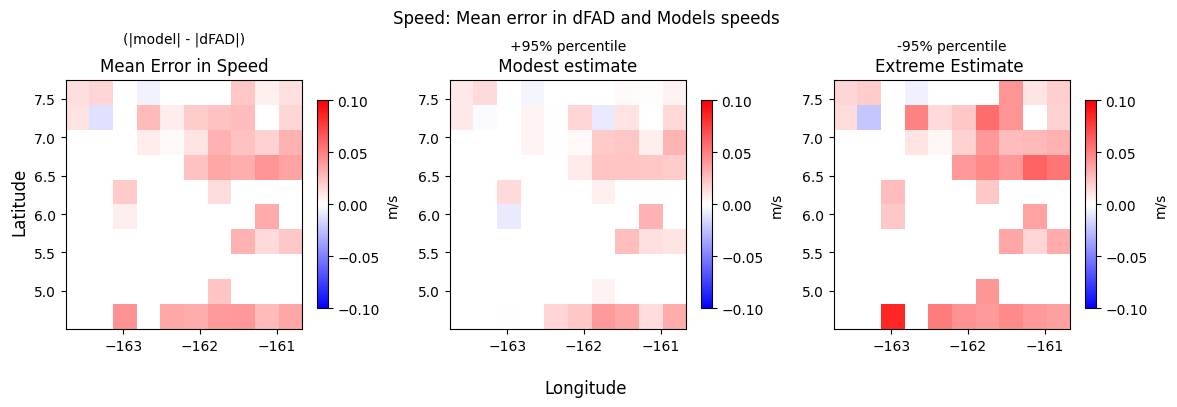

In [49]:

X,Y = np.meshgrid(yedges, xedges)

limslow = -0.1
limshigh = 0.1
color = "bwr"
fig, ax = plt.subplots(1,3,figsize = (12,4))

cbr = ax[0].pcolormesh(X,Y,Values ,cmap = color) ##GnBu
ax[0].set_title(f"Mean Error in Speed")
cbar = fig.colorbar(cbr, shrink = .7)
cbar.set_label("m/s")
cbr.set_clim(limslow,limshigh)

cbr = ax[1].pcolormesh(X,Y,Values_Modest,cmap = color)
ax[1].set_title(f" Modest estimate ")
cbar = fig.colorbar(cbr, shrink = .7)
cbar.set_label("m/s")
cbr.set_clim(limslow,limshigh)

cbr = ax[2].pcolormesh(X,Y,Values_Amplified,cmap = color) #bwr  or Blues_r
ax[2].set_title(f"Extreme Estimate ")
cbar = fig.colorbar(cbr, shrink = .7)
cbar.set_label("m/s")
cbr.set_clim(limslow,limshigh)
#plt.colorbar(cbr,fraction=0.046, pad=0.04)
#ax[0].annotate("Plotting Percent errors \n dFAD moves Faster", (0.5, 1.15), xycoords="axes fraction", ha="center")
ax[0].annotate("(|model| - |dFAD|)", (0.5, 1.15), xycoords="axes fraction", ha="center")
ax[1].annotate("+95% percentile", (0.5, 1.12), xycoords="axes fraction", ha="center")
ax[2].annotate("-95% percentile", (0.5, 1.12), xycoords="axes fraction", ha="center")
ax[0].set_aspect('equal') 
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')  
fig.supxlabel("Longitude")
fig.supylabel("Latitude")
fig.suptitle("Speed: Mean error in dFAD and Models speeds")
fig.tight_layout()
#fig.savefig(r"..\Figures\Speed_Differences.png")

#### Want to plot the Direction and magnitude of the errors.
- dFADx - Modelx
- dFADy - Modely 
- An Arrow pointing in the direction the dfad is with respect to the models movement.
- vector pointing in the correction between the model and dFAD

In [ ]:
delxs, delys, delspeeds = list_of_delta_speeds(ds, average = False)
xValues, errorbars, xedges, yedges, errors = bootstrapping_each_box(lat, lon, delys, bins = 10)
yValues, errorbars, xedges, yedges, errors = bootstrapping_each_box(lat, lon, delys, bins = 10)
X,Y = np.meshgrid(yedges[1:], xedges[1:])

In [55]:
X,Y = np.meshgrid(yedges[1:], xedges[1:])

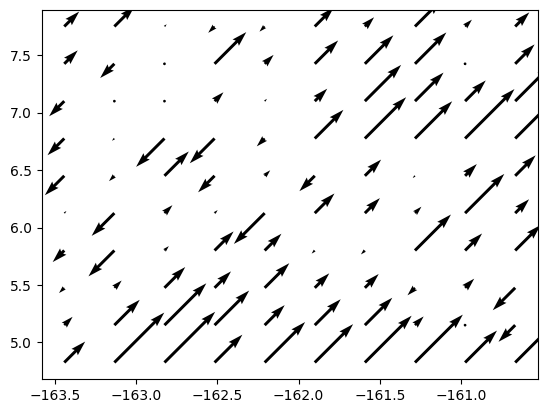

In [56]:
fig, ax = plt.subplots()
ax.quiver(X,Y,xValues, yValues)

##### Breakpoint

In [23]:
nbins = 15
statistic = np.nanmean ## or "Mean" or np.nanmean
## Calculates bin statitics 
x_speeds = binned_statistic_2d(lat, lon, delxs, statistic= statistic, bins = nbins)
y_speeds= binned_statistic_2d(lat,lon,delys,statistic= statistic, bins = nbins)
speeds = binned_statistic_2d(lat,lon,delspeeds,statistic= statistic, bins = nbins)

x_bounds = x_speeds[2]
y_bounds = x_speeds[1]

X,Y = np.meshgrid(x_bounds, y_bounds)

avgxcorrection = np.mean(x_speeds[0])
avgycorrection =np.mean(y_speeds[0])
avgxycorrection =np.mean(speeds[0])

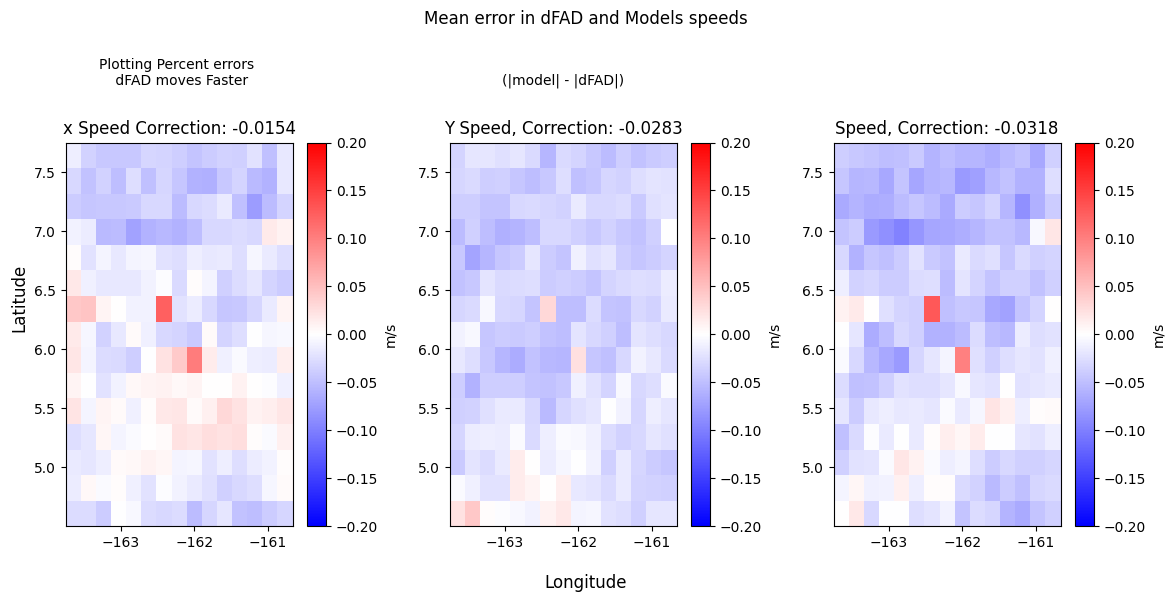

In [24]:
fig, ax = plt.subplots(1,3,figsize = (12,6))
cbr = ax[0].pcolormesh(X,Y,x_speeds[0],cmap = "bwr", norm=colors.CenteredNorm()) ##GnBu
ax[0].set_title(f"x Speed Correction: {avgxcorrection:.4f}")
cbar = fig.colorbar(cbr)
cbar.set_label("m/s")
cbr.set_clim(-0.2,0.2)
cbr = ax[1].pcolormesh(X,Y,y_speeds[0],cmap = "bwr",norm=colors.CenteredNorm())
ax[1].set_title(f"Y Speed, Correction: {avgycorrection:.4f}")
cbar = fig.colorbar(cbr)
cbar.set_label("m/s")
cbr.set_clim(-0.2,0.2)
#cbr.set_clim(0,0.25)
cbr = ax[2].pcolormesh(X,Y,speeds[0],cmap = "bwr",norm=colors.CenteredNorm())
ax[2].set_title(f"Speed, Correction: {avgxycorrection:.4f}")
cbar = fig.colorbar(cbr)
cbar.set_label("m/s")
cbr.set_clim(-0.2,0.2)
#cbr.set_clim(0,0.25)
ax[0].annotate("Plotting Percent errors \n dFAD moves Faster", (0.5, 1.15), xycoords="axes fraction", ha="center")
ax[1].annotate("(|model| - |dFAD|)", (0.5, 1.15), xycoords="axes fraction", ha="center")
fig.supxlabel("Longitude")
fig.supylabel("Latitude")
fig.suptitle("Mean error in dFAD and Models speeds")
fig.tight_layout()
#fig.savefig(rf"..\Figures\Speed_Differences_5.png")


In [ ]:
##need to be compairing magnitude of xspeed and yspeed. 

#### Plotting Speed of dFAD vs Speed of Ocean Model 

In [ ]:
def Palmyra_plot(ax):
    Palmyra = Palmyra_obj()
    ax.scatter(Palmyra.x,Palmyra.y, marker  = "*", color = "r", label = "Palmyra")
    return ax 

#### This is for A simplied version of only speed and Trajectory 

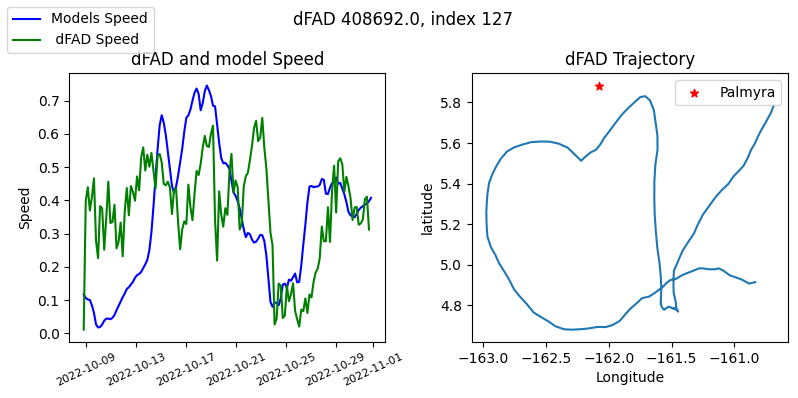

In [ ]:

##6 was interesting was almost oposite
n = np.random.randint(0,301)
n=127
numppoints = ds["numpoints"][n]
times = ds["timelist"][n]
s = pd.Series(times)
without_year = s.dt.strftime('%m-%d')
line2 = ds["y_speed"][n]

fig, ax = plt.subplots(1,2,figsize = (8,4))


##plotting Speeds 
line1, = ax[0].plot(times,ds["mapped_speed"][n], label = "Models Speed", color = "b")
line2, = ax[0].plot(times[:-1],ds["xy_speed"][n], label = " dFAD Speed", color = "g")
#ax[0].plot(times[:-1],Rolling_mean(ds["xy_speed"][n],6), label = "Rolling Mean 1 day", color = "r", linestyle = "--")
ax[0].set_ylabel("Speed")
ax[0].set_title("dFAD and model Speed")
##ax[1,0].plot(times[:-1],ds["delta_speed"][n], label = "Delta Speed", color = "k", linestyle = "--", alpha = 0.8)

OneTrajectory(ax[1], ds,n)
ax[1] = Palmyra_plot(ax[1])
ax[1].legend()
ax[1].set_title("dFAD Trajectory")

ax[0].tick_params(axis='x', rotation=25, labelsize = 8)

#plt.xticks(rotation = 90)
fig.legend(handles = [line1,line2], loc = "upper left")
fig.suptitle(f"dFAD {ds["Name_ID"][n]}, index {n}")
fig.tight_layout()
fig.savefig(rf"..\Figures\speed_plots\Simplied_{n}.png")


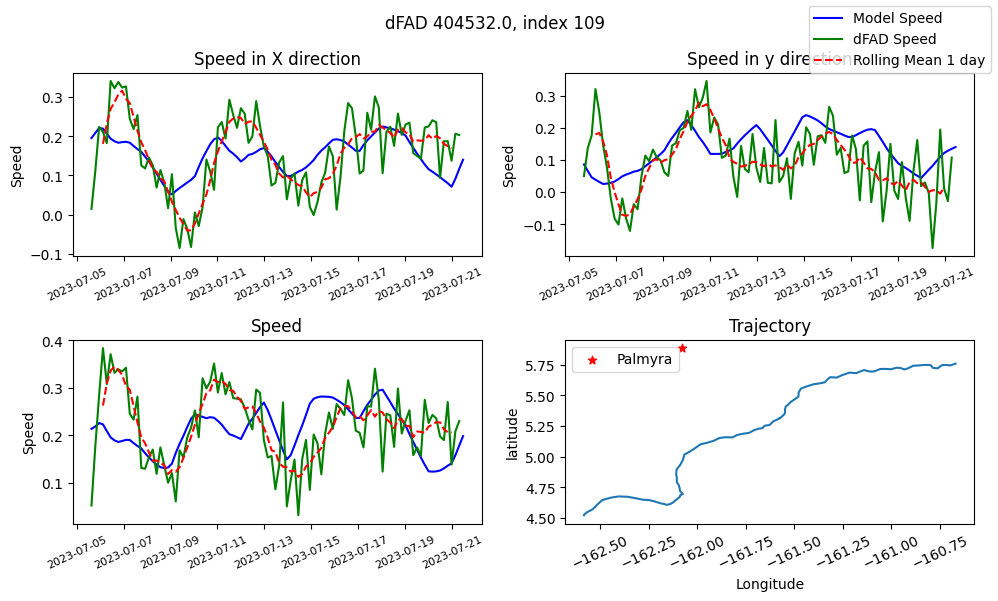

In [ ]:

##6 was interesting was almost oposite
n = np.random.randint(0,301)
numppoints = ds["numpoints"][n]
times = ds["timelist"][n]
s = pd.Series(times)
without_year = s.dt.strftime('%m-%d')
line2 = ds["y_speed"][n]

fig, ax = plt.subplots(2,2,figsize = (10,6))

xspeedavg = Rolling_mean(ds["x_speed"][n], 6)
##Plotting x direction speeds
line1, = ax[0,0].plot(times,ds["mapped_u"][n], label = "Model Speed", color = "b")
line2, = ax[0,0].plot(times[:-1],ds["x_speed"][n], label = "dFAD Speed", color = "g")
#line3,= ax[0,0].plot(times[:-1],ds["deltax_speed"][n], label = "Delta Speed", color = "k", linestyle = "--", alpha = 0.8)
line4, = ax[0,0].plot(times[:-1],Rolling_mean(ds["x_speed"][n],6), label = "Rolling Mean 1 day", color = "r", linestyle = "--")

ax[0,0].set_ylabel("Speed")
ax[0,0].set_title("Speed in X direction")


##plotting Y direction speeds
ax[0,1].plot(times,ds["mapped_v"][n], label = "Models Speed", color = "b")
ax[0,1].plot(times[:-1],ds["y_speed"][n], label = " dFAD Speed", color = "g")
ax[0,1].plot(times[:-1],Rolling_mean(ds["y_speed"][n],6), label = "Rolling Mean 1 day", color = "r", linestyle = "--")
ax[0,1].set_ylabel("Speed")
ax[0,1].set_title("Speed in y direction")
#ax[0,1].plot(times[:-1],ds["deltay_speed"][n], label = "Delta Speed", color = "k", linestyle = "--", alpha = 0.8)

##plotting Speeds 
ax[1,0].plot(times,ds["mapped_speed"][n], label = "Models Speed", color = "b")
ax[1,0].plot(times[:-1],ds["xy_speed"][n], label = " dFAD Speed", color = "g")
ax[1,0].plot(times[:-1],Rolling_mean(ds["xy_speed"][n],6), label = "Rolling Mean 1 day", color = "r", linestyle = "--")
ax[1,0].set_ylabel("Speed")
ax[1,0].set_title("Speed")
##ax[1,0].plot(times[:-1],ds["delta_speed"][n], label = "Delta Speed", color = "k", linestyle = "--", alpha = 0.8)

OneTrajectory(ax[1,1], ds,n)
ax[1,1] = Palmyra_plot(ax[1,1])
ax[1,1].legend()
ax[1,1].set_title("Trajectory")

ax[0,0].tick_params(axis='x', rotation=25, labelsize = 8)
ax[1,0].tick_params(axis='x', rotation=25, labelsize = 8)
ax[0,1].tick_params(axis='x', rotation=25, labelsize = 8)
ax[1,1].tick_params(axis='x', rotation=25)
#plt.xticks(rotation = 90)
fig.legend(handles = [line1,line2,line4])
fig.suptitle(f"dFAD {ds["Name_ID"][n]}, index {n}")
fig.tight_layout()
fig.savefig(rf"..\Figures\speed_plots\{n}.png")




#### Compairing mean speed vs Mean Error. 

In [ ]:
Mspeedxs = []
Mspeedys = []
Mspeeds = []

Merrorxs = []
Merrorys = []
Merrors = []

for i in range(len(ds)):
    Mspeedx = np.nanmean(ds.at[i,"x_speed"])
    Mspeedy = np.nanmean(ds.at[i,"y_speed"])
    Mspeed = np.nanmean(ds.at[i,"xy_speed"])

    Merrorx =  np.abs(np.nanmean(ds.at[i,"deltax_speed"]))
    Merrory =  np.abs(np.nanmean(ds.at[i,"deltay_speed"]))
    Merror  =  np.abs(np.nanmean(ds.at[i,"delta_speed"]))

    Mspeedxs.append(Mspeedx)
    Mspeedys.append(Mspeedy)
    Mspeeds.append(Mspeed)

    Merrorxs.append(Merrorx)
    Merrorys.append(Merrory)
    Merrors.append(Merror)    

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_13600\3731791433.py:2: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[0].scatter(Mspeedxs, Merrorxs, marker = "x",  edgecolors='k')
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_13600\3731791433.py:3: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[1].scatter(Mspeedys, Merrorys,  marker = "x",  edgecolors='k')
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_13600\3731791433.py:4: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[2].scatter(Mspeeds, Merrors,  marker = "x",  edgecolors='k')


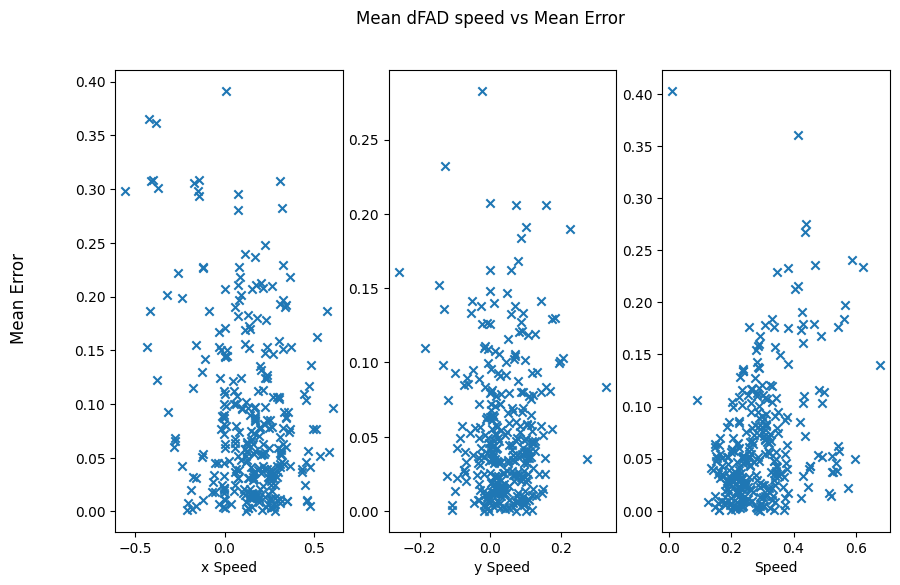

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (10,6))
ax[0].scatter(Mspeedxs, Merrorxs, marker = "x",  edgecolors='k')
ax[1].scatter(Mspeedys, Merrorys,  marker = "x",  edgecolors='k')
ax[2].scatter(Mspeeds, Merrors,  marker = "x",  edgecolors='k')
xlabels = ["x Speed", "y Speed", "Speed"]
for i,n in enumerate(xlabels):
    ax[i].set_xlabel(n)
fig.supylabel("Mean Error")
fig.suptitle("Mean dFAD speed vs Mean Error")
fig.savefig(r"..\Figures\Mean_dFAD_speed_vs_error.png")

#### fourier Transform of Rolling avergage speed and speed 


In [ ]:
from scipy import signal

In [ ]:
n = 200
xspeed = ds.at[n,"x_speed"]
avgspeedx = Rolling_avg_no_nan(xspeed,6)

yspeed = ds.at[n,"y_speed"]
avgspeedy = Rolling_avg_no_nan(yspeed,6)

speed = ds.at[n,"xy_speed"]
avgspeed = Rolling_avg_no_nan(speed,6)

mapped_speed = ds.at[n,"mapped_speed"]

frequeciesx, psdx = signal.welch(xspeed, fs = 0.25, nperseg = 40)
frequeciesxa, psdxa = signal.welch(avgspeedx, fs = 0.25, nperseg = 40)

frequeciesy, psdy = signal.welch(yspeed, fs  =0.25, nperseg = 40)
frequeciesavgy, psdya = signal.welch(avgspeedy, fs  =0.25, nperseg = 40)

frequecies, psd = signal.welch(speed, fs  =0.25,nperseg = 40)
frequeciesavg, psda = signal.welch(avgspeed, fs  =0.25, nperseg = 40)

frequeciesm, psdm = signal.welch(mapped_speed, fs  =0.25,nperseg = 40)


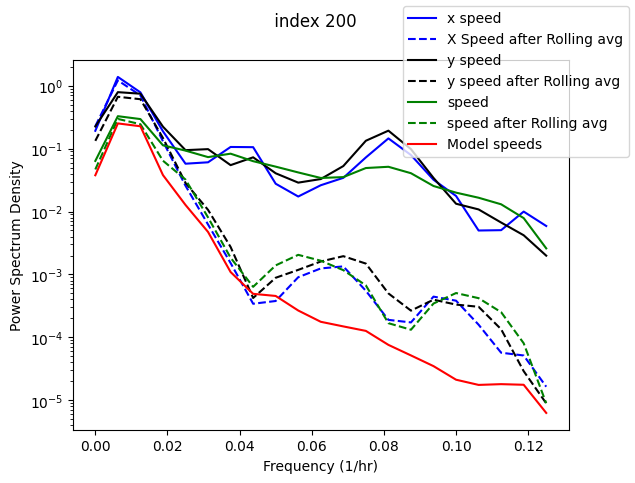

In [ ]:
fig, ax = plt.subplots()
ax.plot(frequeciesx, psdx ,label = "x speed", color = "b")
ax.plot(frequeciesxa,psdxa, label = "X Speed after Rolling avg", color = "b", linestyle = "--")
ax.plot(frequeciesy, psdy, label = "y speed", color = "k")
ax.plot(frequeciesavgy, psdya, label = "y speed after Rolling avg", linestyle = "--", color= "k")
ax.plot(frequecies, psd, label = "speed", color = "g")
ax.plot(frequeciesavg, psda, label = "speed after Rolling avg", color = "g", linestyle = "--")
ax.plot(frequeciesm,psdm, label = "Model speeds", color = "r")
ax.set_xlabel("Frequency (1/hr)")
ax.set_ylabel('Power Spectrum Density')
fig.suptitle(f" index {n}")
fig.legend()
ax.set_yscale("log")
#ax.set_xscale("log")
#fig.savefig(rf"..\Figures\speed_plots\PowerSpectrum_{n}.png")

In [ ]:
bath = xr.open_dataset(r"Data\bath.nc")


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_13600\3417186458.py:2: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cbr = ax.contourf( bath["lon"], bath["lat"], -bath["elevation"], linestyle = "-", cmap = "Blues")


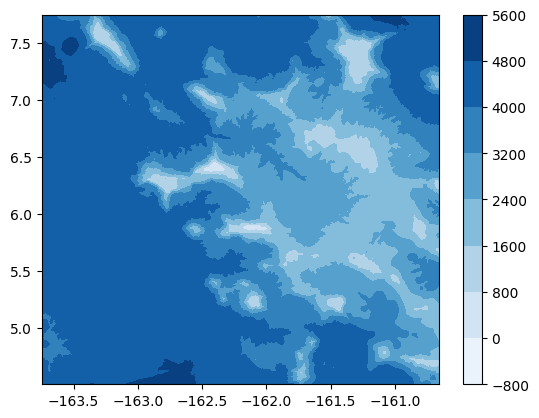

In [ ]:

fig, ax = plt.subplots()
cbr = ax.contourf( bath["lon"], bath["lat"], -bath["elevation"], linestyle = "-", cmap = "Blues")
fig.colorbar(cbr)